<a href="https://colab.research.google.com/github/garvjain7/ai-ml-deeplearning-masterclass/blob/main/NLP1Tokenizer-day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#NLP Hands-On Master Session
#Text Representation & Sentiment Analysis

#Steps:
#1. Text Normalization
#2. Tokenization
#3. Stopword Removal
#4. Bag of Words
#5. TF-IDF
#6. Sentiment Analysis (IMDB Dataset)
#7. Live Prediction

In [ ]:
!pip install nltk wordcloud scikit-learn pandas matplotlib seaborn

In [ ]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
text = "Hello, World! This is an Example Sentence for NLP."

text_lower = text.lower()

text_no_punct = re.sub(r'[^\w\s]', '', text_lower)

print("Original Text:", text)
print("Lowercase:", text_lower)
print("Without Punctuation:", text_no_punct)

Original Text: Hello, World! This is an Example Sentence for NLP.
Lowercase: hello, world! this is an example sentence for nlp.
Without Punctuation: hello world this is an example sentence for nlp


In [ ]:
from nltk.tokenize import word_tokenize

text = "Natural Language Processing is fascinating!"

tokens = word_tokenize(text)

print(tokens)

['Natural', 'Language', 'Processing', 'is', 'fascinating', '!']


In [ ]:
stop_words = set(stopwords.words('english'))

filtered_words = []

for word in tokens:
    if word.lower() not in stop_words:
        filtered_words.append(word)

print("After Stopword Removal:", filtered_words)

After Stopword Removal: ['Natural', 'Language', 'Processing', 'fascinating', '!']


In [ ]:
sentences = [
"I love NLP",
"I love Machine Learning"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(sentences)

print("Vocabulary:", vectorizer.get_feature_names_out())

print("Bag of Words Matrix:\n", X.toarray())

Vocabulary: ['learning' 'love' 'machine' 'nlp']
Bag of Words Matrix:
 [[0 1 0 1]
 [1 1 1 0]]


In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(sentences)

print("Vocabulary:", vectorizer.get_feature_names_out())

print("TF-IDF Matrix:\n", X.toarray())

Vocabulary: ['learning' 'love' 'machine' 'nlp']
TF-IDF Matrix:
 [[0.         0.57973867 0.         0.81480247]
 [0.6316672  0.44943642 0.6316672  0.        ]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Copy of IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):

    text = text.lower()  # lowercase

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs

    text = re.sub(r'<.*?>', '', text)  # remove HTML tags

    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation + numbers

    words = text.split()

    words = [word for word in words if word not in stop_words]  # remove stopwords

    text = " ".join(words)

    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    return text

In [ ]:
df['review'] = df['review'].apply(clean_text)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review'])

y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8864


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8501


In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8802


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

KeyboardInterrupt: 

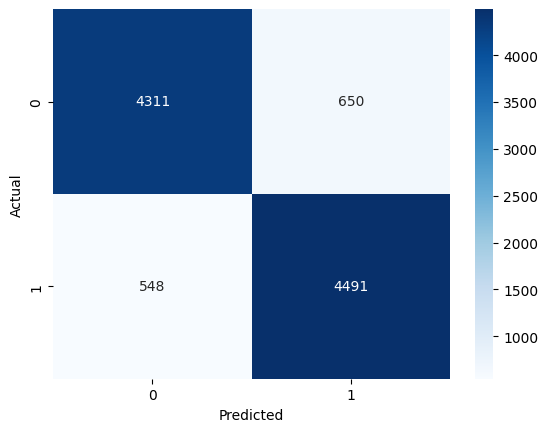

In [ ]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

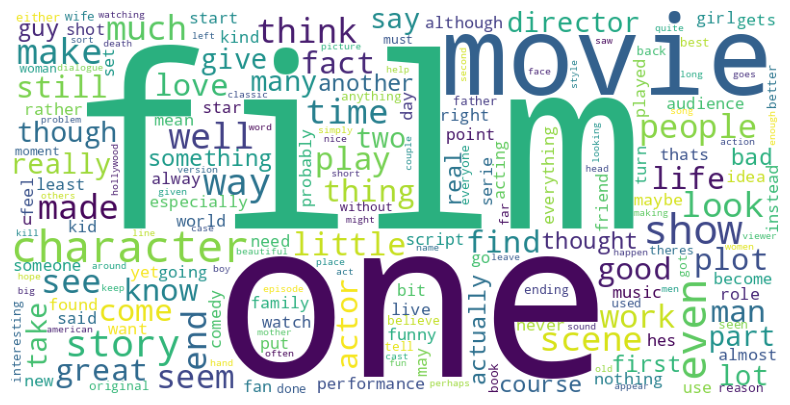

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [ ]:
review = input("Enter a movie review: ")

review_vector = vectorizer.transform([review])

prediction = model.predict(review_vector)

if prediction[0] == "positive":
    print("😊 Positive Review")
else:
    print("😞 Negative Review")

Enter a movie review: This is a fantastic movie I have seen in my life
😊 Positive Review


Word2Vec

In [ ]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['review'].apply(word_tokenize)

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

model_w2v = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.0 MB/s eta 0:00:00


In [ ]:
import numpy as np

def get_sentence_vector(tokens):
    vectors = []

    for word in tokens:
        if word in model_w2v.wv:
            vectors.append(model_w2v.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [ ]:
X_w2v = np.array([get_sentence_vector(tokens) for tokens in df['tokens']])

In [ ]:
y = df['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=100)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Word2Vec Accuracy:", accuracy_score(y_test, pred))

Word2Vec Accuracy: 0.8621


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Glove

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

embeddings_index = {}

with open('/content/drive/My Drive/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/glove.6B.100d.txt'

In [ ]:
def sentence_vector(sentence):
    words = sentence.lower().split()
    vectors = []

    for word in words:
        if word in embeddings_index:
            vectors.append(embeddings_index[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [ ]:
X_embed = np.array([sentence_vector(text) for text in df['review']])

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X_embed, y, test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("GloVe Accuracy:", accuracy_score(y_test, pred))

GloVe Accuracy: 0.7947


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


PCA

In [ ]:
words = ["king","queen","man","woman","boy","girl","prince","princess"]

In [ ]:
word_vectors = [embeddings_index[w] for w in words]

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced = pca.fit_transform(word_vectors)

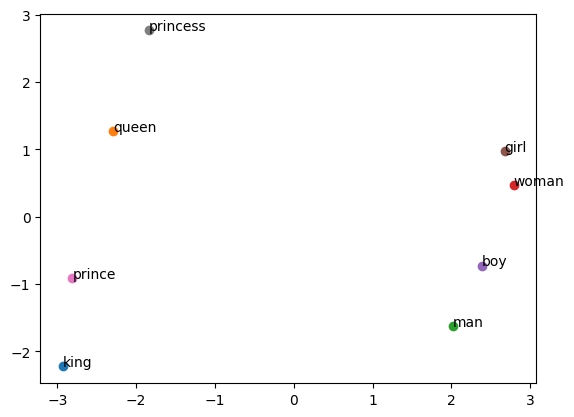

In [ ]:
import matplotlib.pyplot as plt

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x, y, word)

plt.show()